<a href="https://colab.research.google.com/github/nmwiley808/csci164/blob/main/in%20class%20programming%20assignments/01_group_vision_model_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  AI Project Report
## Team: **Human–AI Collaborative Intelligence**

---

###  Project Title  
**Exploring Intelligent Agents and Decision-Making in AI Systems**

---

###  Team Members

#### **Noah Wiley**
**Expertise:**  
- Artifical Intelligence & Deep Learning
- Programming (Python, C++, C)
- Cybersecuirty Fundamentals

**Contributions:**  
- Guided model selection and undrestanding of vision-language architecurtes

- Implemented and ran Hugging Face models in Colab
- Analyzed model outputs for accuracy, detail, and hallucinations
- Interpreted results using AI and perception concepts from class

### **Saul Mendoza**
**Expertise:**
- Programming (Java, C++, Python)
- Web Programming & Artifical Intelligence
- Data Handling and Experiment Organization

**Contributions:**
- Helped organize and document model outputs
- Supported comparison of results across multiple models
- Interpreted results using AI and perception concepts from class

---

#### **ChatGPT (AI Assistant)**  
**Role:** AI Collaborator & Learning Support Tool  
**Expertise:**  
- Concept explanation and brainstorming  
- Code generation, debugging, and refactoring  
- Documentation and formatting assistance  

**Contributions:**  
- Assisted with idea generation and alternative approaches  
- Provided explanations of AI concepts and algorithms  
- Helped draft and refine code, comments, and written sections  
- Supported clarity, organization, and presentation  

---

###  Collaboration Statement
This project was completed through an intentional **human–AI collaboration**.  
All AI-assisted content was critically evaluated, modified, and validated by the human team member.  
The final submission reflects **David Ruby’s understanding, reasoning, and responsibility** for the work.

---

###  Course
**Undergraduate Artificial Intelligence**

---


# Vision w/ Hugging Face

The Hugging Face **Transformers** library provides high-level pipelines for working with
computer vision and multimodal models, including image captioning and prompted
vision–language generation. These pipelines abstract away much of the preprocessing,
model loading, and inference logic, allowing you to experiment quickly with
state-of-the-art models.

---

## 📘 Core Documentation

- **Vision & Multimodal Tasks (Overview)**  
  https://huggingface.co/docs/transformers/tasks/vision

- **Pipelines API (How `pipeline()` works)**  
  https://huggingface.co/docs/transformers/main_classes/pipelines

---

## Common Image Captioning Models

| Model | Promptable | Verbosity | Teaching Use |
|------|------------|-----------|--------------|
| ViT-GPT2 (`nlpconnect/vit-gpt2-image-captioning`) | ❌ | Low–Medium | Simple intro to image captioning |
| BLIP (`Salesforce/blip-image-captioning-base/large`) | ✅ | Medium–High | Best all-around for multimodal prompting |
| BLIP-2 (`Salesforce/blip2-flan-t5-*`) | ✅✅ | High | Advanced vision + instruction tuning |
| GIT (`microsoft/git-base`) | ❌ | Medium | More literal, factual captions |
| OFA (`OFA-Sys/ofa-base`) | ⚠️ | Medium | Unified multimodal model concept |

---

## 🔗 Model-Specific References (Optional Deep Dives)

- **BLIP Models (Image Captioning & VQA)**  
  https://huggingface.co/Salesforce/blip-image-captioning-base

- **BLIP-2 (Vision + Instruction-Following LLMs)**  
  https://huggingface.co/docs/transformers/model_doc/blip-2

- **GIT (Generative Image-to-Text)**  
  https://huggingface.co/microsoft/git-base

- **OFA (Unified Multimodal Model)**  
  https://huggingface.co/OFA-Sys/ofa-base

---

> **Note:** While these models are accessed using the `image-to-text` pipeline,
> some (such as BLIP and BLIP-2) also accept text prompts that *condition* how the
> image is interpreted and described. This makes them a useful stepping stone toward
> more advanced multimodal and agentic AI systems.




https://huggingface.co/docs/transformers/pipeline_tutorial

In [ ]:
# https://drive.google.com/file/d/1GD7RJZ_wh0d0RbR7OqklD2Ux7aZUHNOH/view?usp=sharing
# https://drive.google.com/file/d/1J44Ib1D2t9uxklJf_gXQ3jQGbaYWSugB/view?usp=sharing

In [2]:

## !pip install -q gdown


# Download the file from Google Drive
# The file ID is extracted from the URL: https://drive.google.com/file/d/1GD7RJZ_wh0d0RbR7OqklD2Ux7aZUHNOH/view?usp=sharin
#                                        https://drive.google.com/file/d/1y6Mtj8P0CSGWBoRmpfg0yUSg7VR0224d/view?usp=sharing
#                                        https://drive.google.com/file/d/1bbmDywLf_BxjyMC2w79uGa1eyg_HWcHG/view?usp=sharing

!gdown 1GD7RJZ_wh0d0RbR7OqklD2Ux7aZUHNOH
!gdown 1y6Mtj8P0CSGWBoRmpfg0yUSg7VR0224d

# fn= "fresnostatehat.JPG"
# fn= "tireonpavement.JPG"

Downloading...
From: https://drive.google.com/uc?id=1GD7RJZ_wh0d0RbR7OqklD2Ux7aZUHNOH
To: /content/fresnostatehat.JPG
100% 4.41M/4.41M [00:00<00:00, 80.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1y6Mtj8P0CSGWBoRmpfg0yUSg7VR0224d
To: /content/tireonpavement.png
100% 707k/707k [00:00<00:00, 44.0MB/s]


(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

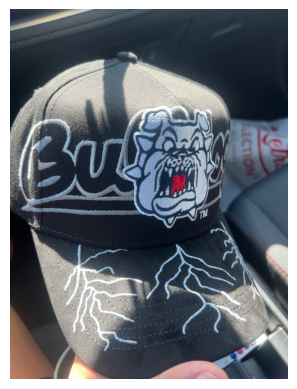

In [3]:
#To look at the image run this
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("fresnostatehat.JPG")

plt.imshow(img)
plt.axis("off")


In [ ]:
import warnings
warnings.filterwarnings(action = 'ignore')

In [ ]:
from transformers import pipeline
from transformers.utils import logging
logging.set_verbosity(40)

In [7]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch

# Direct loading of model and processor to bypass pipeline task issues
model_id = "Salesforce/blip-image-captioning-base"
processor_blip_base = BlipProcessor.from_pretrained(model_id)
model_blip_base = BlipForConditionalGeneration.from_pretrained(model_id)

# Define a function to mimic the pipeline's behavior for simple image captioning
def captioner_function(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor_blip_base(images=image, return_tensors="pt")
    generated_ids = model_blip_base.generate(**inputs)
    caption = processor_blip_base.decode(generated_ids[0], skip_special_tokens=True)
    return [{"generated_text": caption}]

# Assign the function to 'captioner' to maintain compatibility with subsequent calls
captioner = captioner_function

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

# Load the processor and model directly to bypass the pipeline's 'dtype' bug
model_id = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(model_id)
model = BlipForConditionalGeneration.from_pretrained(model_id)

# Open the image
image = Image.open(fn).convert("RGB")

# Preprocess and generate the caption
inputs = processor(images=image, return_tensors="pt")
outputs = model.generate(**inputs)

# Decode and print the result
caption = processor.decode(outputs[0], skip_special_tokens=True)
print(f"Generated Caption: {caption}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Generated Caption: a young girl in red hockey uniform holding a stick


## Prompted Image Captioning

Traditional image captioning models generate a short description of an image with no additional guidance. While useful, these captions are often brief and generic. **Prompted image captioning** extends this idea by allowing a *text prompt* to accompany the image, guiding how the model interprets and describes what it sees.

In prompted image captioning, the model receives **both visual input and textual context** at the same time. The text prompt acts as an instruction, question, or stylistic guide that shapes the generated caption.

For example, the same image may produce very different outputs depending on the prompt:

- *“Describe the image.”*  
- *“Describe the image in vivid botanical detail.”*  
- *“What season does this image suggest?”*  
- *“List the visible objects and their colors.”*

Models such as **BLIP** and **BLIP-2** are explicitly designed to support this form of multimodal prompting. Internally, these models combine image embeddings with language model instructions, enabling them to:
- Generate longer and more descriptive captions
- Answer questions about an image
- Adjust tone, detail level, or focus based on the prompt

Prompted image captioning is an important step toward **multimodal reasoning systems**. Rather than passively describing images, models can be *steered* to interpret visual information in task-specific ways—an ability that later becomes central in **agentic AI systems**, where perception is guided by goals and instructions.


In [ ]:
#captioner2 = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
captioner2 = pipeline("image-to-text", model="Salesforce/blip2-flan-t5-xl")


In [ ]:
# Basic caption
print(captioner_blip2("tulips.jpg"))

# Prompted caption (steer style/detail)
print(captioner_blip2("tulips.jpg", prompt="Describe the image in vivid botanical detail:"))

# More verbose caption via generation params
print(captioner_blip2("tulips.jpg", prompt="Describe the image in detail:"))

In [ ]:
# Basic caption
print(captioner_blip2("dog.jpg"))

# More verbose caption via generation params
print(captioner_blip2("dog.jpg", prompt="Describe the image in detail:"))

In [ ]:
vqa = pipeline(
    "visual-question-answering",
    model="Salesforce/blip2-flan-t5-xl"
)

In [ ]:
vqa(image="dog.jpg", question="Describe the dog’s appearance and posture in detail.")

In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch

processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-flan-t5-xl")

image = Image.open("dog.jpg").convert("RGB")

inputs = processor(
    image,
    text="Describe the dog’s appearance and posture in detail.",
    return_tensors="pt"
)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=60
    )

print(processor.decode(output[0], skip_special_tokens=True))